# FINA 4150 Quantitative Methods for Financial Derivatives
## Group (5?)
## Project 1: Step-Up Autocallable

CHOU, Chung Hei Johnny: [Sor I forgot]  
LAM, Yau Tsun:          [11551192467]  
LEUNG, Yuk Shing Cyrus: [1155193611]  
YAU, Tsz Lam:           [1155192228]  

```Things before you run:  
If you are using VS Code, look on top right and remember to select the right kernel!  
When u run the notebook u can select the kernel right, go and select a virtual environment and then VS code would make a terminal for u to install things through pip!  
Right now I am using a venv of python 3.14.  
And after you selected the right kernel, remember to pip install the right library that are required in the code.  
We should be using the latest libraries so no worries in the versions and all those but we will see haha.  

Other things to note:  
Everytime when u come back to the thing and try to work again: GIT PULL FIRST!
Everytime before you want to stage and commit things and git push all those: GIT PULL FIRST!
Everytime after you implemented anything: Stage and commit and GIT PUSH! Or else others may do ur stuff and when then u push itll become a fork.  
```

### Note for Keith:
- **AI Involvement**:  
  AI (Various LLMs in GitHub Copilot) is used only to aid on planning, and the framework of the code, all core logic are hand coded (For now). 

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import time
import scipy.stats as stats
import scipy.optimize as optimize
import scipy.interpolate as interpolate

## Market Data Classes

In [58]:
class Curves:
    """Store and retrieve time-dependent risk-free rates and dividend yield using cubic spline interpolation. Uses bootstrapping for instantaneous rates."""
    cs = None
    def __init__(self, x, y, bootstrap: bool = True):
        if bootstrap:
            t = y.copy()
            for i in range(1, len(y)):
                # print(f"i = {i}")
                # print(f"Original y = {y[i]}, y diff = {y[i]-y[i-1]}, x diff = {x[i]-x[i-1]}")
                t[i] = ((1 + y[i]) ** x[i] / (1 + y[i-1]) ** x[i-1]) ** (1 / (x[i] - x[i-1])) - 1
                # print(f"Final y = {y[i]}")
            y = t
        # print(y)
        self.cs = interpolate.CubicSpline(x, y)
    
    def __call__(self, t: float) -> float: # This means when u make an object like rf = Curves(whatever), then you can just do rf(t) to get the interpolated value
        return self.cs(t)

In [ ]:
class VolatilitySurface:
    """Store and retrieve local volatility values using curve fitting via tanh."""
    
    def __init__(self):
        pass
    
    def volatility(self, S: float, t: float) -> float:
        """Get local volatility at spot level S and time t."""
        pass


In [ ]:
class CorrelationMatrix:
    """Store and manage the 3x3 correlation matrix with Cholesky decomposition."""
    
    def __init__(self):
        pass
    
    def get_matrix(self):
        """Get the correlation matrix."""
        pass
    
    def get_cholesky_decomposition(self):
        """Get the Cholesky decomposition L such that rho = L @ L.T."""
        pass
    
    def validate(self):
        """Validate that the matrix is positive definite."""
        pass


## Contract & Barrier Classes

In [84]:
class Barrier:
    """Represent a knock-out or knock-in barrier."""
    x = None
    y = None
    cont = None 
    def __init__(self, x, y, cont: bool = False):
        self.x = x
        self.y = y
        self.cont = cont
    
    def __call__(self, t: float, S: float) -> bool:
        """Check if the barrier is triggered at the given spot price and time."""
        if self.cont:
            x = np.searchsorted(self.x, t, side='right', sorter=None) - 1
            return S >= self.y[x]
        else:
            for i in range(len(self.x)):
                if t == self.x[i] and S >= self.y[i]:
                    return True
            return False

In [ ]:
class Payoff:
    """Base class for payoff calculations."""
    
    def __init__(self):
        pass
    
    def calculate(self, S_path, coupon, observation_dates):
        """Calculate payoffs for a given path."""
        pass


In [ ]:
class AutocallablePayoff(Payoff):
    """Payoff logic for step-up autocallable notes."""
    
    def __init__(self):
        pass
    
    def calculate(self, S_path, coupon, observation_dates):
        """Calculate payoffs for autocallable product."""
        pass


In [ ]:
class Contract:
    """Represent the autocallable note contract with all its terms."""
    
    def __init__(self):
        pass
    
    def validate(self):
        """Validate contract consistency."""
        pass


## Market Data & Configuration Classes

In [ ]:
class MarketData:
    """Aggregate all market data: spot prices, curves, surfaces, and correlation matrix."""
    
    def __init__(self):
        pass
    
    def get_spot(self, asset_id: int) -> float:
        """Get initial spot price for asset."""
        pass
    
    def get_rate(self, t: float) -> float:
        """Get risk-free rate at time t."""
        pass
    
    def get_dividend_yield(self, asset_id: int, t: float) -> float:
        """Get dividend yield for asset at time t."""
        pass
    
    def get_local_vol(self, asset_id: int, S: float, t: float) -> float:
        """Get local volatility for asset at spot S and time t."""
        pass
    
    def get_correlation_matrix(self):
        """Get the correlation matrix."""
        pass


In [ ]:
class SimulationConfig:
    """Configuration parameters for Monte Carlo simulation."""
    
    def __init__(self):
        pass
    
    def validate(self):
        """Validate configuration consistency."""
        pass
    
    def get_time_steps(self):
        """Calculate total number of time steps."""
        pass


## Path Generation Classes

In [ ]:
class PathGenerator:
    """Base class for multi-asset path generation."""
    
    def __init__(self):
        pass
    
    def generate(self, market_data, config):
        """Generate correlated price paths."""
        pass


In [ ]:
class GBMLocalVolPathGenerator(PathGenerator):
    """Generate GBM paths with time-dependent rates, yields, and local volatility."""
    
    def __init__(self):
        pass
    
    def generate(self, market_data, config):
        """Generate correlated price paths using local vol."""
        pass
    
    def _apply_dynamics(self):
        """Apply GBM dynamics with local volatility."""
        pass


## Pricing Engine Classes

In [ ]:
class PathEvaluator:
    """Evaluate payoffs for individual price paths."""
    
    def __init__(self):
        pass
    
    def evaluate_path(self, S_path, contract, coupon, market_data):
        """Calculate discounted payoff for a single path."""
        pass


In [ ]:
class Pricer:
    """Main pricing engine for the autocallable note."""
    
    def __init__(self, market_data, contract, config, path_generator):
        pass
    
    def price(self, coupon: float) -> float:
        """Calculate the price of the note for a given coupon."""
        pass


## Solver & Validation Classes

In [ ]:
class CouponSolver:
    """Solve for the coupon that matches the target price using root-finding."""
    
    def __init__(self, pricer, target_price):
        pass
    
    def solve(self, lower_bound, upper_bound, tolerance):
        """Find the coupon that makes the note price equal to target price."""
        pass


In [ ]:
class ModelValidator:
    """Validate model correctness through sanity checks."""
    
    def __init__(self, pricer):
        pass
    
    def test_zero_coupon(self):
        """Test with coupon = 0."""
        pass
    
    def test_high_coupon(self):
        """Test with high coupon value."""
        pass
    
    def test_hard_to_hit_ko(self):
        """Test with KO barrier set very high."""
        pass
    
    def test_impossible_ki(self):
        """Test with KI barrier that cannot be triggered."""
        pass


In [ ]:
class ConvergenceAnalyzer:
    """Analyze convergence of pricing estimates as number of paths increases."""
    
    def __init__(self, pricer):
        pass
    
    def analyze(self, coupon, path_counts):
        """Run pricing with different path counts and analyze convergence."""
        pass
    
    def plot_convergence(self):
        """Plot price against number of paths."""
        pass


## Pricing

In [59]:
us_rf = pd.read_csv('us_rf.csv')
kr_rf = pd.read_csv('kr_rf.csv')
hk_rf = pd.read_csv('hk_rf.csv')
spx_div = pd.read_csv('spx_div.csv')
kospi2_div = pd.read_csv('kospi2_div.csv')
hscei_div = pd.read_csv('hscei_div.csv')


In [60]:
us_rf = Curves(us_rf['Tenor'].values, us_rf['Yield'].values)
kr_rf = Curves(kr_rf['Tenor'].values, kr_rf['Yield'].values)
hk_rf = Curves(hk_rf['Tenor'].values, hk_rf['Yield'].values)
spx_div = Curves(spx_div['Tenor'].values, spx_div['Yield'].values)
kospi2_div = Curves(kospi2_div['Tenor'].values, kospi2_div['Yield'].values)
hscei_div = Curves(hscei_div['Tenor'].values, hscei_div['Yield'].values)

In [30]:
# Now using the rf like a function would work
us_rf(2)

array(0.03368)

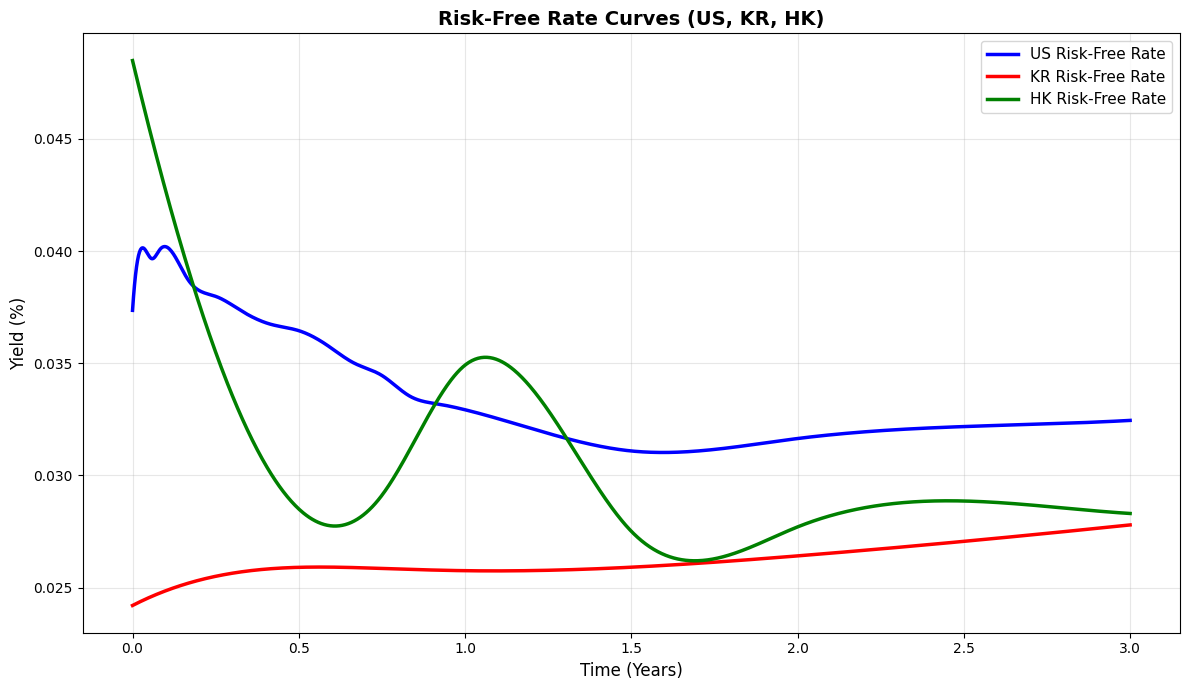

In [61]:
# AI generated plots


plt.figure(figsize=(12, 7))

# Plot all three risk-free rate curves
x = np.linspace(0, 3, 1000)
y_us = us_rf(x)
y_kr = kr_rf(x)
y_hk = hk_rf(x)

plt.plot(x, y_us, linewidth=2.5, label='US Risk-Free Rate', color='blue')
plt.plot(x, y_kr, linewidth=2.5, label='KR Risk-Free Rate', color='red')
plt.plot(x, y_hk, linewidth=2.5, label='HK Risk-Free Rate', color='green')

plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title('Risk-Free Rate Curves (US, KR, HK)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

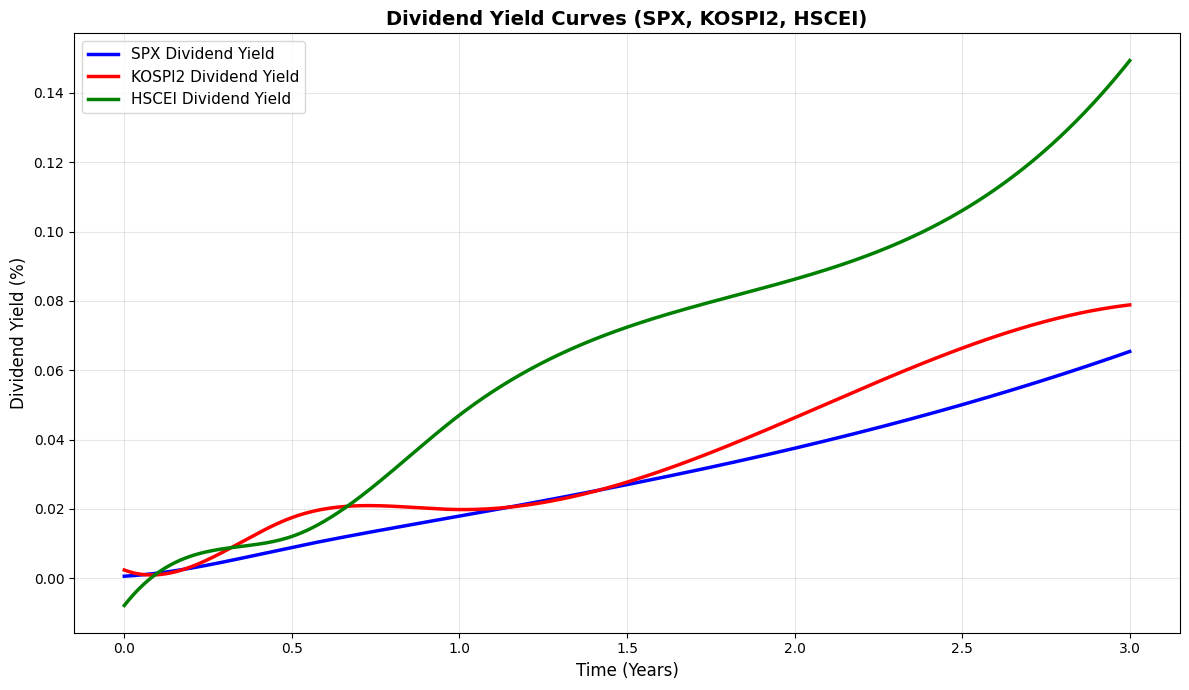

In [62]:
# AI generated plots

plt.figure(figsize=(12, 7))

# Plot all three dividend yield curves
x = np.linspace(0, 3, 1000)
y_spx = spx_div(x)
y_kospi2 = kospi2_div(x)
y_hscei = hscei_div(x)

plt.plot(x, y_spx, linewidth=2.5, label='SPX Dividend Yield', color='blue')
plt.plot(x, y_kospi2, linewidth=2.5, label='KOSPI2 Dividend Yield', color='red')
plt.plot(x, y_hscei, linewidth=2.5, label='HSCEI Dividend Yield', color='green')

plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Dividend Yield (%)', fontsize=12)
plt.title('Dividend Yield Curves (SPX, KOSPI2, HSCEI)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

In [79]:
b = Barrier(x=[0, 1.0, 1.5, 2.0, 2.5, 3.0], y=[130, 125, 120, 115, 110, 105], cont=True)



In [85]:
b(0.3, 137)

True

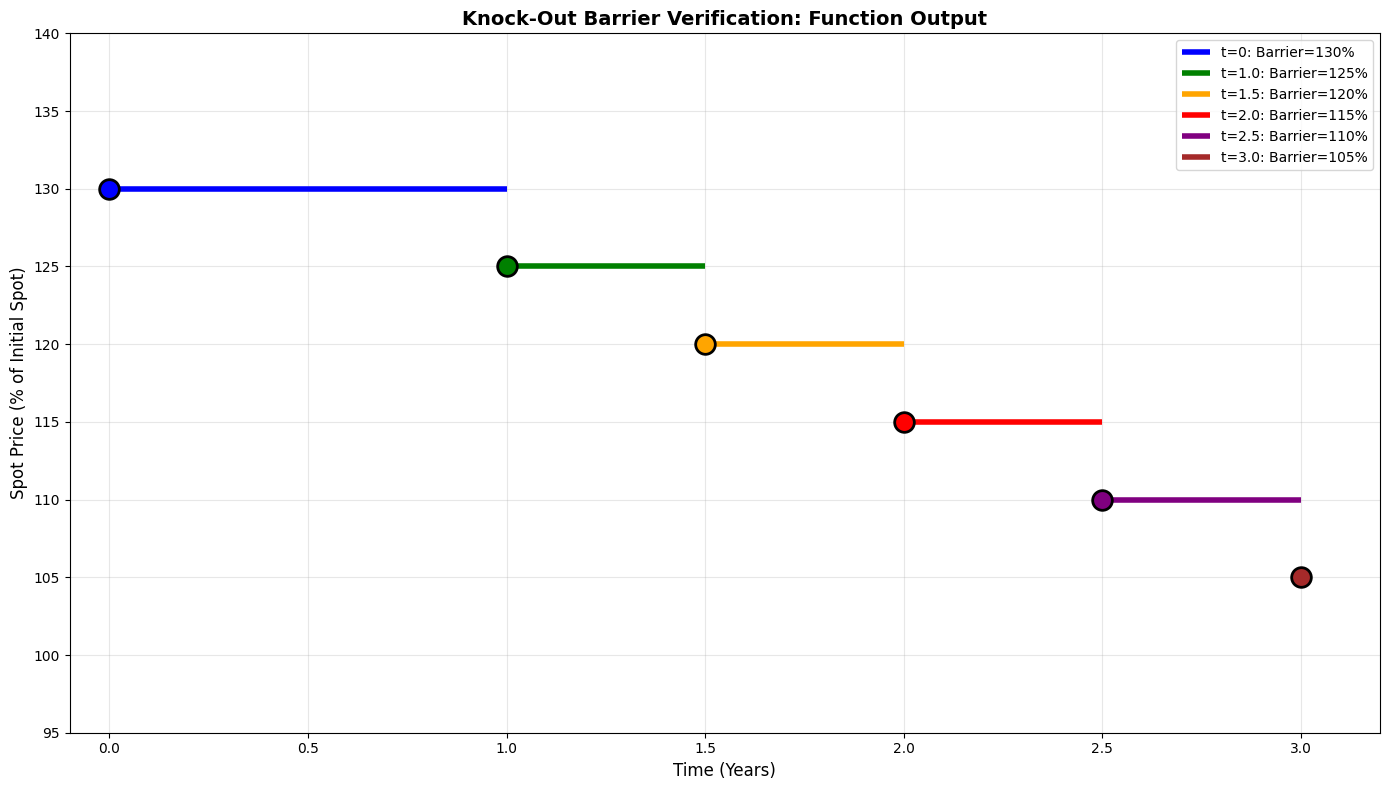


=== Barrier Verification Table ===
Time     Barrier Level   Test Spot=110   Test Spot=125  
-----------------------------------------------------
0.0      130.0           False           False          
1.0      125.0           False           True           
1.5      120.0           False           True           
2.0      115.0           False           True           
2.5      110.0           True            True           
3.0      105.0           True            True           


In [87]:
plt.figure(figsize=(14, 8))

# Test the barrier function at different spot prices and time points
spot_prices = np.linspace(50, 150, 100)

# Plot horizontal step function showing barrier at each time period
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']
for i in range(len(b.x)):
    current_time = b.x[i]
    current_barrier = b.y[i]
    
    # Determine the next time point (or end at maturity)
    if i < len(b.x) - 1:
        next_time = b.x[i + 1]
    else:
        next_time = 3.0
    
    # Draw horizontal line at barrier level from current_time to next_time
    plt.hlines(current_barrier, current_time, next_time, colors=colors[i], linewidth=4, label=f't={current_time}: Barrier={current_barrier}%')
    plt.scatter([current_time], [current_barrier], color=colors[i], s=200, marker='o', zorder=5, edgecolors='black', linewidth=2)

plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Spot Price (% of Initial Spot)', fontsize=12)
plt.title('Knock-Out Barrier Verification: Function Output', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='best')
plt.xlim(-0.1, 3.2)
plt.ylim(95, 140)
plt.tight_layout()
plt.show()

# Print verification table
print("\n=== Barrier Verification Table ===")
print(f"{'Time':<8} {'Barrier Level':<15} {'Test Spot=110':<15} {'Test Spot=125':<15}")
print("-" * 53)
for t in b.x:
    trigger_110 = b(t, 110)
    trigger_125 = b(t, 125)
    barrier_level = b.y[list(b.x).index(t)]
    
    print(f"{t:<8.1f} {barrier_level:<15.1f} {str(trigger_110):<15} {str(trigger_125):<15}")